# SPIDER ML Task 2_Base ML Level 2
## Custom LSTM for Weather Forecasting

In this notebook, I will build a custom LSTM from scratch for weather forecasting.The model will use previous weather observations to predict future temperature values.

## Problem Statement

The goal is to build a custom LSTM manually without using any built-in recurrent layer.We will use the Jena Climate dataset, prepare hourly data, create sequence windows, train the model,and evaluate predictions.

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Setup

We first check the device and set basic parameters for training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Load Dataset

We load the Jena Climate dataset and prepare it for hourly forecasting.
The original data is recorded every 10 minutes, so we will downsample it by averaging every 6 rows

In [ ]:
df = pd.read_csv("jena_climate_2009_2016.csv.zip")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
print(df.columns)
print(df.shape)

Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='object')
(420451, 15)


Now we will clean the data, convert the date column, and downsample it to hourly values.

## Cleaning and Preparing Data

We convert the time column, sort the data and keep only the features needed for forecasting.

In [ ]:
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")

df = df.sort_values("Date Time").reset_index(drop=True)

df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## Downsample to Hourly Data

The original dataset has 10-minute observations.
We average every 6 rows to create hourly observations.

In [ ]:
df_hourly = df.groupby(np.arange(len(df)) // 6).mean(numeric_only=True)
df_hourly.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,996.523333,-8.261667,265.161667,-9.063333,93.883333,3.271667,3.071667,0.200000,1.918333,3.081667,1308.973333,0.468333,0.940000,177.500000
1,996.545000,-8.203333,265.221667,-9.026667,93.733333,3.288333,3.081667,0.205000,1.926667,3.093333,1308.713333,0.323333,0.711667,172.016667
2,996.781667,-8.751667,264.653333,-9.591667,93.583333,3.146667,2.945000,0.200000,1.840000,2.955000,1311.805000,0.236667,0.606667,192.966667
3,997.011667,-8.936667,264.450000,-9.846667,93.050000,3.101667,2.885000,0.215000,1.803333,2.891667,1313.051667,0.163333,0.565000,169.216667
4,997.236667,-9.445000,263.923333,-10.450000,92.316667,2.980000,2.751667,0.231667,1.718333,2.756667,1315.951667,0.340000,0.753333,136.260000


## Selecting Features

We keep a small set of useful weather features for forecasting

In [ ]:
features = ["T (degC)", "p (mbar)", "rho (g/m**3)", "wv (m/s)", "wd (deg)"]
data = df_hourly[features].copy()

data.head()

,T (degC),p (mbar),rho (g/m**3),wv (m/s),wd (deg)
0,-8.261667,996.523333,1308.973333,0.468333,177.500000
1,-8.203333,996.545000,1308.713333,0.323333,172.016667
2,-8.751667,996.781667,1311.805000,0.236667,192.966667
3,-8.936667,997.011667,1313.051667,0.163333,169.216667
4,-9.445000,997.236667,1315.951667,0.340000,136.260000


## Handling Missing Values

We remove or fill missing values before creating training windows

In [ ]:
data = data.fillna(method="ffill").fillna(method="bfill")

/tmp/ipykernel_1181/4071329852.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="ffill").fillna(method="bfill")


## Normalizing the data  
We will scale the features so training becomes more stable

In [ ]:
data_mean = data.mean()
data_std = data.std()

data_scaled = (data - data_mean) / data_std
data_scaled.head()

,T (degC),p (mbar),rho (g/m**3),wv (m/s),wd (deg)
0,-2.104010,0.874744,2.325408,-1.132408,0.037898
1,-2.097080,0.877337,2.318900,-1.231206,-0.037022
2,-2.162223,0.905655,2.396286,-1.290258,0.249222
3,-2.184202,0.933175,2.427491,-1.340225,-0.075279
4,-2.244593,0.960097,2.500080,-1.219850,-0.525573


## Creating Sequences

We use the previous 72 hours of weather data to predict the next 12 hours of temperature

In [ ]:
def create_sequences(data_array, input_len=72, output_len=12):
    X, y = [], []
    for i in range(len(data_array) - input_len - output_len):
        X.append(data_array[i:i+input_len])
        y.append(data_array[i+input_len:i+input_len+output_len, 0])
    return np.array(X), np.array(y)

data_array = data_scaled.values
X, y = create_sequences(data_array, input_len=72, output_len=12)


print(X.shape, y.shape)

(69992, 72, 5) (69992, 12)


## Train-Test Split

We split the time series into training and testing sets without shuffling.

In [ ]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(55993, 72, 5) (13999, 72, 5) (55993, 12) (13999, 12)


## Converting to Tensors

We convert the numpy arrays into PyTorch tensors for training.

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

## Creating DataLoaders

i prepare mini-batches for efficient training.

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Custom LSTM Cell

We now implement the LSTM cell manually.This includes the input gate, forget gate, output gate, candidate state, cell state update, and hidden state update.

In [ ]:
class CustomLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        self.W_ih = nn.Linear(input_size, 4 * hidden_size)
        self.W_hh = nn.Linear(hidden_size, 4 * hidden_size)

    def forward(self, x, h_prev, c_prev):
        gates = self.W_ih(x) + self.W_hh(h_prev)
        i, f, o, g = torch.chunk(gates, 4, dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c_next = f * c_prev + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next

## Custom LSTM Model

We build a simple LSTM model using the custom LSTM cell.
The final hidden state is used to predict the next 12 hours of temperature.

In [ ]:
class CustomLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.cells = nn.ModuleList()
        for layer in range(num_layers):
            self.cells.append(
                CustomLSTMCell(input_size if layer == 0 else hidden_size, hidden_size)
            )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        h = [torch.zeros(batch_size, self.hidden_size, device=x.device) for _ in range(self.num_layers)]
        c = [torch.zeros(batch_size, self.hidden_size, device=x.device) for _ in range(self.num_layers)]

        for t in range(seq_len):
            inp = x[:, t, :]
            for layer in range(self.num_layers):
                h[layer], c[layer] = self.cells[layer](inp, h[layer], c[layer])
                inp = h[layer]

        out = self.fc(h[-1])
        return out

## Model Setup

We define the model, loss function, and optimizer.

In [ ]:
input_size = X_train.shape[2]
hidden_size = 64
output_size = 12
num_layers = 1

model = CustomLSTM(input_size, hidden_size, output_size, num_layers=num_layers).to(device)

criterion = nn.HuberLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Training Loop

We train the custom LSTM and track the loss after each epoch.

In [ ]:
train_losses = []
test_losses = []

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    test_running_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            test_running_loss += loss.item()

    test_loss = test_running_loss / len(test_loader)
    test_losses.append(test_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch 1/10 | Train Loss: 0.0631 | Test Loss: 0.0350
Epoch 2/10 | Train Loss: 0.0305 | Test Loss: 0.0322
Epoch 3/10 | Train Loss: 0.0279 | Test Loss: 0.0303
Epoch 4/10 | Train Loss: 0.0261 | Test Loss: 0.0315
Epoch 5/10 | Train Loss: 0.0249 | Test Loss: 0.0288
Epoch 6/10 | Train Loss: 0.0240 | Test Loss: 0.0295
Epoch 7/10 | Train Loss: 0.0232 | Test Loss: 0.0298
Epoch 8/10 | Train Loss: 0.0223 | Test Loss: 0.0292
Epoch 9/10 | Train Loss: 0.0216 | Test Loss: 0.0300
Epoch 10/10 | Train Loss: 0.0209 | Test Loss: 0.0299


## Evaluation

We now compute Huber Loss, MAE, and MSE on the test set.

In [ ]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y_batch.numpy())

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

huber = np.mean(np.where(
    np.abs(all_preds - all_targets) < 1,
    0.5 * (all_preds - all_targets) ** 2,
    np.abs(all_preds - all_targets) - 0.5
))
mae = mean_absolute_error(all_targets, all_preds)
mse = mean_squared_error(all_targets, all_preds)

print("Huber Loss:", huber)
print("MAE:", mae)
print("MSE:", mse)

Huber Loss: 0.029802088
MAE: 0.1803693324327469
MSE: 0.05962856113910675


## Prediction Plot

We plot the predicted temperature against the actual temperature for one test window.

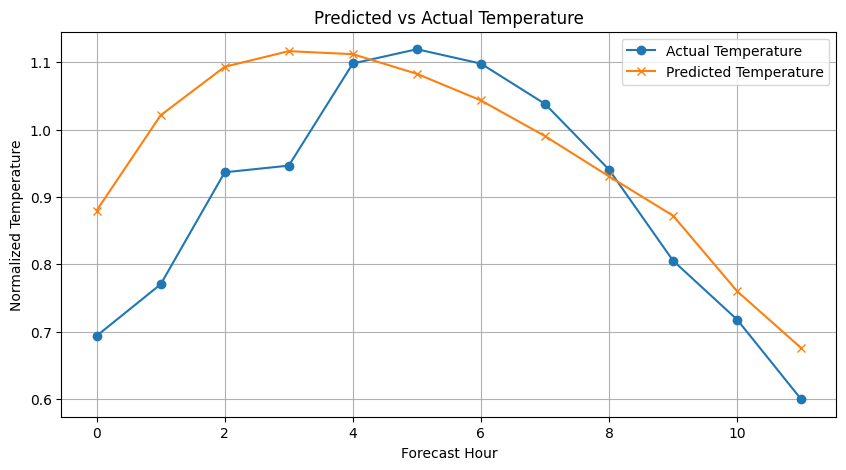

In [ ]:
true_vals = all_targets[0]
pred_vals = all_preds[0]

plt.figure(figsize=(10, 5))
plt.plot(true_vals, label="Actual Temperature", marker="o")
plt.plot(pred_vals, label="Predicted Temperature", marker="x")
plt.xlabel("Forecast Hour")
plt.ylabel("Normalized Temperature")
plt.title("Predicted vs Actual Temperature")
plt.legend()
plt.grid(True)
plt.show()

## Saving Model Weights

We save the trained model for submission

In [ ]:
torch.save(model.state_dict(), "custom_lstm_level2.pth")
print("Model saved as custom_lstm_level2.pth")

Model saved as custom_lstm_level2.pth


## Conclusion

In this notebook, I implemented a custom LSTM manually for weather forecasting.The model was trained on hourly Jena Climate data and evaluated using Huber Loss, MAE, and MSE.